Arc one only 
{(22, ('rl_arc_based', 'one_only', (0.33, 0.33, 0.34))): (0.06787878787878789, 0.07641007237274956, 0.12192714875291584, 1.0, 0.586520091959978, 0.07649979065733596, 0.9263747472934984, 0.01), (21, ('rl_arc_based', 'one_only', (0.33, 0.33, 0.34))): (0.0677555958862674, 0.07791527630220413, 0.13294378189109518, 0.9983291562238931, 0.599704650936354, 0.07863352736087627, 0.9251932128751065, 0.01), (15, ('rl_arc_based', 'one_only', (0.33, 0.33, 0.34))): (0.06053268765133172, 0.06646097521368784, 0.1131253782902021, 1.0, 0.587330202255009, 0.06731720279307342, 0.9352042423048986, 0.01), (7, ('rl_arc_based', 'one_only', (0.33, 0.33, 0.34))): (0.06791995148574893, 0.07567052659780311, 0.1261274670318221, 0.9975349219391948, 0.5914302276899295, 0.07599797576876136, 0.926775830471049, 0.01), (6, ('rl_arc_based', 'one_only', (0.33, 0.33, 0.34))): (0.0647921760391198, 0.06445345112861849, 0.11340832156898463, 0.9975429975429976, 0.5913582450390226, 0.06463560878607101, 0.9353728360

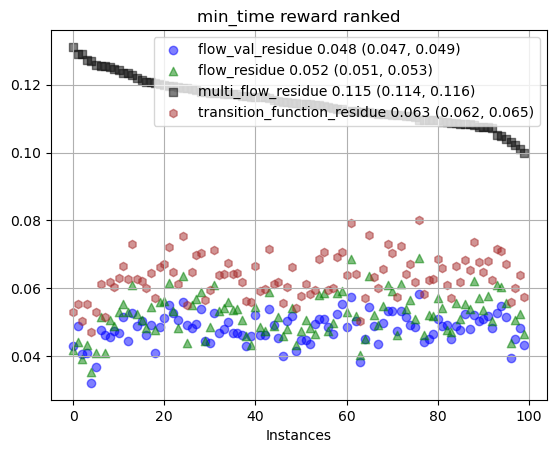

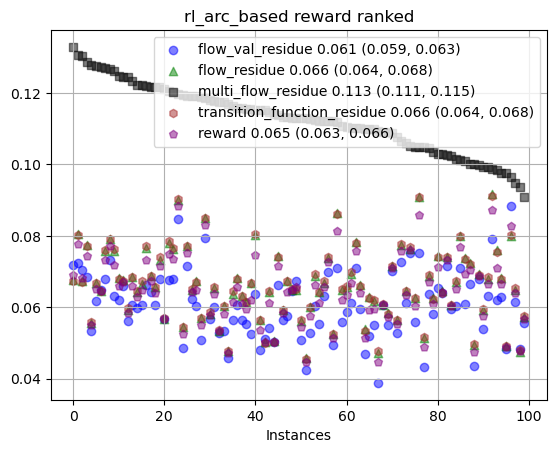

In [5]:
"""
Real : RL Heuristics vs baseline heuristics
"""

# Import pickle
import pickle

import numpy as np

import matplotlib.pyplot as plt

import statsmodels.api as sm

import seaborn as sns

import pylab as py

import scipy.stats as stats


from IPython.display import clear_output

import os

os.chdir('C:\\Users\\HADDAM\\Documents\\Python Scripts\\multi_flow_decomp\\')

from utils.utils_stats import mean_confidence_interval, test_twoind_sample



##########################  Baseline heuristics handling  ########################## 
"""
{"res_key_metadata":res_key_metadata,
"res_value_metadata":res_value_metadata, 
"data":deepcopy(dict(dict_results))}
"""
#path_baseline_heuristics = "results/real/MFDS_vs_RL/results_lieu_saint_baseline_heuristics.pickle"
#path_baseline_heuristics = "results/results_lieusaint2_heuristics.pickle"
#path_baseline_heuristics = "results/real/MFDS_vs_RL/lieu_saint/stored_results_executions/nodes=95_pairs=20_random/results_baseline_heuristics_random_95.pickle"
path_baseline_heuristics = "results/real/MFDS_vs_RL/versailles/gpickle/capacity_pairs/results_versailles_heuristics_capacity.pickle"
with open(path_baseline_heuristics, 
          'rb') as handle:
    file = pickle.load(handle)
    test_names = file["res_key_metadata"]
    metric_names = file["res_value_metadata"]
    data_res_heur = file["data"]

nb_instances = len({id_inst for id_inst, _ in data_res_heur.keys()})

"""
dict_results[(ind_instance, test)] = (flow_val_res, flow_res, m_flow_res, 
                                        prop_fsupp, prop_sp, trans_func_res)
test   -->    ["min_time", 
              "max_capacity", 
              "trans_func", 
              "random"]
"""
# Unzip to display (each metric on one list)
heurs_name = "min_time"
metrics_instances_heurs = []
for j in range(len(metric_names)):
    metrics_instances_heurs.append([(id_inst, 
                                     data_res_heur[(id_inst, (heurs_name,))][j]) 
                                        for id_inst in range(nb_instances)])
    if j == 2: # Sort the perfs of associated to the multiflow residue
        metrics_instances_heurs[-1].sort(key = lambda x : -x[1])



##########################  RL heuristics handling  ##########################
"""
{"res_key_metadata":res_key_metadata,
"res_value_metadata":res_value_metadata, 
"data":deepcopy(dict(dict_results))}
"""
#path_rl_heuristics = "results/real/MFDS_vs_RL/results_lieu_saint_rl_heuristics_lr=0,075.pickle"
#path_rl_heuristics = "results/results_lieu_saint_rl_heuristics2.pickle"
path_rl_heuristics = "results/real/MFDS_vs_RL/versailles/gpickle/capacity_pairs/discount_by_cost/results_versailles_rl_heuristics_capacity_nb_episodes=50_lr=0,01_2.pickle"
with open(path_rl_heuristics, 
          'rb') as handle:
    file = pickle.load(handle)
    test_infos = file["res_key_metadata"]
    metric_names = file["res_value_metadata"]
    data = file["data"]

"""
dict_results[(ind_instance, test_infos)] = (flow_val_res, flow_res, 
                                            m_flow_res, prop_fsupp, 
                                            prop_sp, trans_func_res,
                                            reward)
test_infos = (path_type_selector, path_card_criteria, lr_rate, (coeff1, coeff2, coeff3))
"""

# The set of all the learning rates
lr_rates = set(lr_rate for _, (_, _, lr_rate, _) in data)
# The data associated to the arc based case
data_arc_based = {(ind_instance, test_infos):data[(ind_instance, test_infos)]
                                                for (ind_instance, test_infos) in data
                                                    if test_infos[0] == "rl_arc_based" and\
                                                        test_infos[1] == "one_only" and\
                                                            test_infos[3][-1] != 0}

# Calculate the best learning rate for the node_based case
mean_rew_by_lr_rate = {np.mean([data_arc_based[(ind_instance, test_infos)][-1] 
                                    for (ind_instance, test_infos) in data_arc_based
                                        if test_infos[2] == lr_rate]):lr_rate 
                                            for lr_rate in lr_rates}
lr_rate_max_arc_based = mean_rew_by_lr_rate[max(mean_rew_by_lr_rate.keys())]


# Filter to leave only the best value of the learning parameter for the arc based case
data_res_rl_arc_based = {(ind_instance, 
                            (test_infos[0], 
                            test_infos[1], 
                            test_infos[3])):data_arc_based[(ind_instance, test_infos)]+(lr_rate_max_arc_based,)
                                                for (ind_instance, test_infos) in data_arc_based
                                                    if test_infos[2] == lr_rate_max_arc_based}
print("Arc one only ")
print(data_res_rl_arc_based)
# Unzip to display (each metric on one list)
metrics_instances_rl_arc_based = []
test_info = ("rl_arc_based", "one_only", (0.33, 0.33, 0.34))
#test_info = ("rl_arc_based", "one_for_each", (0.44, 0.44, 0.12))
#test_info = ("rl_arc_based", "one_for_each", (0.5, 0.49, 0.01))
for j in range(len(metric_names)):
    metrics_instances_rl_arc_based.append([(id_inst, 
                                            data_res_rl_arc_based[(id_inst, test_info)][j])
                                                for id_inst in range(nb_instances)])
    if j == 2: # Sort the perfs of associated to the multiflow residue
        metrics_instances_rl_arc_based[-1].sort(key = lambda x : -x[1])

# Diplay the curves
#save_path = "results/real/MFDS_vs_RL/versailles/capacity/rl_vs_baseline/discount_by_cost/nb_episodes=50/2/"
save_path = None
colors = ['b', 'g', 'k', 'r', 'y', 'brown', 'purple', 'orange',  'gray', 'pink']
markers = ["o", "^", "s", "x", "*", "h", "p", "+"]
bins = 'auto'
#bins = 100
#force = None
force = "bootstrap"
with_pval_norm = False
fig = plt.figure()
indices = [0, 1, 2, 5]
for i in range(len(metric_names)):
    if i in indices:
        # Construct list of values of the metric for each instance
        vals = [e[1] for e in metrics_instances_heurs[i]]
        # Process mean and reward
        mean_ = np.mean(vals)
        std_ = np.std(vals, ddof=1)
        ci, pval_norm = mean_confidence_interval(vals, 
                                                confidence_normality_test = 0.95,
                                                force = force,
                                                confidence_level = 0.95)
        name = heurs_name
        conf_int_str = "("+str(round(ci[0], 3))+", "+str(round(ci[1], 3))+")"
        added_pval_norm = " ^ "+str(round(pval_norm,3)) if with_pval_norm else ""
        label = metric_names[i]+" "+str(round(mean_,3))+" "+conf_int_str+added_pval_norm
        # Plot figure 1
        plt.scatter(list(range(len(vals))), 
                    vals, 
                    color = colors[i],
                    marker = markers[i], 
                    alpha = 0.5, 
                    label = label)
plt.xlabel("Instances")
#plt.ylabel(metric_names[i])
plt.legend(loc="upper right")
plt.grid(visible = True)
plt.title(heurs_name+" "+metric_names[i]+" ranked")
        

fig = plt.figure()
indices.append(6)
for i in range(len(metric_names)):
    if i in indices:
        # Construct list of values of the metric for each instance
        if i == 6:
            vals = [1-e[1] for e in metrics_instances_rl_arc_based[i]]
        else:
            vals = [e[1] for e in metrics_instances_rl_arc_based[i]]
        # Process mean and reward
        mean_ = np.mean(vals)
        std_ = np.std(vals, ddof=1)
        ci, pval_norm = mean_confidence_interval(vals, 
                                                confidence_normality_test = 0.95,
                                                force = force,
                                                confidence_level = 0.95)
        name = "rl_arc_based"
        conf_int_str = "("+str(round(ci[0], 3))+", "+str(round(ci[1], 3))+")"
        added_pval_norm = " ^ "+str(round(pval_norm,3)) if with_pval_norm else ""
        label = metric_names[i]+" "+str(round(mean_,3))+" "+conf_int_str+added_pval_norm
        # Plot figure 1
        plt.scatter(list(range(len(vals))), 
                    vals, 
                    color = colors[i],
                    marker = markers[i], 
                    alpha = 0.5, 
                    label = label)
plt.xlabel("Instances")
#plt.ylabel(metric_names[i])
plt.legend(loc="upper right")
plt.grid(visible = True)
plt.title(name+" "+metric_names[i]+" ranked")

plt.show()

#clear_output(wait=False)
